In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
X ,y = mnist["data"], mnist["target"]

In [3]:
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

In [5]:
X_test , X_train, y_test, y_train = X[60000:],X[:600000], y[60000:],y[:600000]

In [6]:
from sklearn.neighbors import KNeighborsClassifier

In [7]:
neigh = KNeighborsClassifier()

In [8]:
neigh.fit(X_train,y_train)

KNeighborsClassifier()

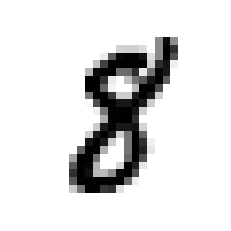

In [9]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[41]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

plt.show()

In [10]:
neigh.predict([some_digit])

array(['8'], dtype=object)

In [ ]:
from sklearn.model_selection import cross_val_score


cross_val_score(neigh,X_train,y_train,cv=3,scoring='accuracy')

In [ ]:
y_train_pred = cross_val_predict(neigh, X_train, y_train, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(y_train, y_train_pred)

In [ ]:
conf_mx

In [ ]:
def plot_confusion_matrix(matrix):
    """If you prefer color and a colorbar"""
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(matrix)
    fig.colorbar(cax)

In [ ]:
plt.matshow(conf_mx)
plt.show()

In [ ]:
neigh.predict([X_test[599]])

In [ ]:
y_test[599]

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

In [ ]:
cross_val_score(neigh, X_train_scaled, y_train, cv=3,scoring="accuracy")